# Ensemble modeliai ir metrikos su Python (Breast Cancer, sklearn)

Naudojamas `sklearn.datasets.load_breast_cancer` duomenų rinkinys. Tikslas – dvejetainė klasifikacija (0/1).  
Toliau pateikiami paprasti ansambliai (voting), Random Forest, Gradient Boosting, hiperparametrų derinimas ir SHAP interpretacija.

Pastaba: tekste nenaudojama kreipinių forma, o paaiškinimai pateikiami trumpai ir praktiškai.


## 1. Bibliotekos ir duomenų paruošimas

Duomenys iš `sklearn` jau yra suformuoti kaip skaitiniai požymiai, todėl papildomas kodavimas dažniausiai nereikalingas.  
Toliau atliekamas train/test padalinimas su `stratify`, kad klasių proporcijos išliktų panašios abiejuose rinkiniuose.

Dažna klaida: nenaudoti `stratify` ir gauti iškreiptą klasių pasiskirstymą test rinkinyje.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier

# Reproducibility
RANDOM_STATE = 42


In [3]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True).round(3)


((455, 30),
 (114, 30),
 target
 1    0.626
 0    0.374
 Name: proportion, dtype: float64)

In [4]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
X.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [6]:
X.shape

(569, 30)

## 2. Vertinimo funkcija ir metrikos

Praktikoje dažniausiai vertinama ne viena metrika.  
- **Accuracy** gali klaidinti, jei klasės nesubalansuotos.  
- **ROC AUC** vertina, kaip gerai modelis skiria klases pagal tikimybes.  
- **Confusion matrix** parodo klaidų tipą (FP, FN).

Dažna klaida: vertinti tik pagal accuracy ir nežiūrėti į klaidų struktūrą.


In [7]:
def evaluate_classifier(model, X_te, y_te, name="model"):
    """Prints a compact metrics report and returns a dict."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    
    # For ROC AUC we need positive-class probabilities
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_proba)
    else:
        y_proba = None
        auc = np.nan
    
    print(f"{name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  ROC AUC : {auc:.4f}" if np.isfinite(auc) else "  ROC AUC : n/a")
    print("  Confusion matrix:\n", confusion_matrix(y_te, y_pred))
    print("  Classification report:\n", classification_report(y_te, y_pred, digits=3))
    
    return {
        "name": name,
        "accuracy": acc,
        "roc_auc": auc,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


## 3. Simple ensemble models (Voting)

Voting ansamblis apjungia kelių bazinių modelių prognozes.

- **Hard voting**: galutinė klasė = daugumos balsas.  
- **Soft voting**: galutinė tikimybė = tikimybių vidurkis (dažniausiai suteikia daugiau lankstumo).

Praktinė pastaba: **soft voting** įmanomas tik tada, kai visi modeliai turi `predict_proba`.


In [8]:
lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
rf_base = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

# Hard voting
vote_hard = VotingClassifier(
    estimators=[("lr", lr), ("dt", dt), ("rf", rf_base)],
    voting="hard"
)

# Soft voting
vote_soft = VotingClassifier(
    estimators=[("lr", lr), ("dt", dt), ("rf", rf_base)],
    voting="soft"
)

vote_hard.fit(X_train, y_train)
vote_soft.fit(X_train, y_train)

res_hard = evaluate_classifier(vote_hard, X_test, y_test, "Voting (hard)")
res_soft = evaluate_classifier(vote_soft, X_test, y_test, "Voting (soft)")


Voting (hard)
  Accuracy: 0.9561
  ROC AUC : n/a
  Confusion matrix:
 [[39  3]
 [ 2 70]]
  Classification report:
               precision    recall  f1-score   support

           0      0.951     0.929     0.940        42
           1      0.959     0.972     0.966        72

    accuracy                          0.956       114
   macro avg      0.955     0.950     0.953       114
weighted avg      0.956     0.956     0.956       114

Voting (soft)
  Accuracy: 0.9561
  ROC AUC : 0.9934
  Confusion matrix:
 [[39  3]
 [ 2 70]]
  Classification report:
               precision    recall  f1-score   support

           0      0.951     0.929     0.940        42
           1      0.959     0.972     0.966        72

    accuracy                          0.956       114
   macro avg      0.955     0.950     0.953       114
weighted avg      0.956     0.956     0.956       114



### Trumpa interpretacija

Soft voting dažnai laimi tada, kai modelių tikimybės yra skirtingo „stiprumo“.  
Pavyzdžiui, viena situacija gali būti „ribinė“ (0.51), o kita – labai užtikrinta (0.95). Tikimybių vidurkis tokią informaciją išlaiko.

Dažna klaida: naudoti hard voting vien dėl paprastumo, nors tikimybės būtų naudingos (pvz., slenksčio keitimui).


Accuracy abiem modeliams yra 0.956. Tai reiškia, kad apie 95.6% testinių stebėjimų buvo klasifikuoti teisingai. Modelis klysta maždaug 4–5 atvejais iš 100.

Confusion matrix rodo, kad iš 42 neigiamos klasės atvejų (0 klasė) 39 buvo atpažinti teisingai, o 3 – suklysti. Iš 72 teigiamos klasės atvejų (1 klasė) 70 buvo atpažinti teisingai, o 2 – suklysti. Tai reiškia, kad modelis gerai atpažįsta abi klases ir klaidų skaičius yra nedidelis.

Precision 1 klasei yra 0.959. Tai reiškia, kad kai modelis prognozuoja piktybinį naviką, apie 96% atvejų ši prognozė yra teisinga. Recall 1 klasei yra 0.972, vadinasi, modelis aptinka apie 97% visų realiai piktybinių atvejų.

Hard ir soft voting modelių accuracy yra identiškas, tačiau soft voting turi ROC AUC = 0.9934. ROC AUC matuoja modelio gebėjimą atskirti klases pagal tikimybes. Reikšmė labai arti 1 rodo itin gerą atskyrimą. Hard voting ROC AUC nepateikiamas, nes jis naudoja tik galutinę klasę, o ne tikimybes.

Praktinė išvada: nors galutinės klasifikacijos abiem atvejais vienodos, soft voting modelis geriau išnaudoja tikimybinę informaciją ir suteikia lankstesnę galimybę keisti sprendimo slenkstį. Todėl soft voting dažniausiai laikomas pranašesniu pasirinkimu, kai svarbi rizikos vertinimo analizė.


## 4. Random Forest

Random Forest yra daugelio sprendimų medžių ansamblis (bagging).  
Kiekvienas medis treniruojamas su atsitiktine eilučių imtimi (bootstrap) ir atsitiktine požymių imtimi skaidymuose.

Praktinė reikšmė: sumažėja persimokymas, prognozės tampa stabilesnės.


In [9]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
res_rf = evaluate_classifier(rf, X_test, y_test, "Random Forest")


Random Forest
  Accuracy: 0.9561
  ROC AUC : 0.9931
  Confusion matrix:
 [[39  3]
 [ 2 70]]
  Classification report:
               precision    recall  f1-score   support

           0      0.951     0.929     0.940        42
           1      0.959     0.972     0.966        72

    accuracy                          0.956       114
   macro avg      0.955     0.950     0.953       114
weighted avg      0.956     0.956     0.956       114



Accuracy yra 0.956, tai reiškia, kad apie 95.6% testinių atvejų klasifikuojami teisingai. Modelio bendras tikslumas yra aukštas ir praktiškai identiškas ankstesniems ensemble modeliams.

Confusion matrix rodo, kad iš 42 neigiamos klasės atvejų 39 buvo atpažinti teisingai, o 3 – suklysti. Iš 72 teigiamos klasės atvejų 70 buvo atpažinti teisingai, o 2 – suklysti. Tai reiškia, kad modelis gana gerai atskiria abi klases ir klaidų skaičius nedidelis.

Precision 1 klasei yra 0.959. Tai reiškia, kad kai modelis prognozuoja piktybinį atvejį, apie 96% šių prognozių yra teisingos. Recall 1 klasei yra 0.972, todėl modelis aptinka apie 97% visų realiai piktybinių atvejų. Medicininiame kontekste aukštas recall yra itin svarbus, nes mažina riziką nepastebėti pavojingo atvejo.

ROC AUC reikšmė 0.9931 rodo labai stiprų klasių atskyrimą pagal tikimybes. Modelis geba beveik idealiai atskirti teigiamus ir neigiamus atvejus.

Praktinė išvada: Random Forest modelis demonstruoja stabilų ir aukštą veikimą tiek pagal tikslumą, tiek pagal klasių atskyrimo gebėjimą. Rezultatai rodo, kad modelis gerai subalansuotas ir neakcentuoja vienos klasės sąskaita kitos.


## 5. Feature importance (Random Forest)

`feature_importances_` rodo, kurie požymiai dažniausiai buvo naudingi skaidymuose.  
Tai **nėra** priežastingumo įrodymas, bet tai yra greitas būdas suprasti, kas modelyje „dirba“ labiausiai.

Dažna klaida: interpretuoti `feature_importances_` kaip „požymis sukelia rezultatą“.


In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(30)


worst area                 0.130008
worst perimeter            0.127948
worst concave points       0.127183
worst radius               0.092807
mean concave points        0.089029
mean radius                0.054538
mean concavity             0.050924
mean perimeter             0.049703
mean area                  0.042165
area error                 0.037021
worst concavity            0.033653
worst texture              0.017897
radius error               0.016940
worst compactness          0.016705
mean texture               0.013547
mean compactness           0.013398
worst smoothness           0.013386
worst symmetry             0.009908
perimeter error            0.008243
worst fractal dimension    0.006412
mean smoothness            0.006283
concave points error       0.006136
concavity error            0.005774
texture error              0.004873
fractal dimension error    0.004681
symmetry error             0.004464
compactness error          0.004397
mean symmetry              0

Feature importance rodo, kurie požymiai turėjo didžiausią įtaką modelio sprendimams. Kuo didesnė reikšmė, tuo dažniau ir stipriau tas požymis buvo naudojamas sprendimų medžių skaidymuose.

Didžiausią svarbą turi **worst area**, **worst perimeter** ir **worst concave points**. Tai reiškia, kad blogiausios, labiausiai išreikštos naviko charakteristikos turi didžiausią įtaką galutinei prognozei. Modelis labiausiai remiasi ekstremaliomis naviko savybėmis, o ne tik vidutinėmis reikšmėmis.

**Worst radius** ir **mean concave points** taip pat turi reikšmingą įtaką. Tai rodo, kad naviko dydis ir kraštų forma yra svarbūs klasifikacijos veiksniai.

Mažesnę, bet vis tiek reikšmingą įtaką turi **mean radius**, **mean concavity**, **mean perimeter**, **mean area** ir **area error**. Šie rodikliai papildo modelio sprendimą, tačiau jų svoris mažesnis.

Praktinė išvada: modelis daugiausia sprendžia remdamasis naviko dydžio ir struktūros rodikliais. Svarbu suprasti, kad feature importance neatspindi priežastinio ryšio – ji parodo tik tai, kurie požymiai labiausiai prisidėjo prie modelio prognozių.


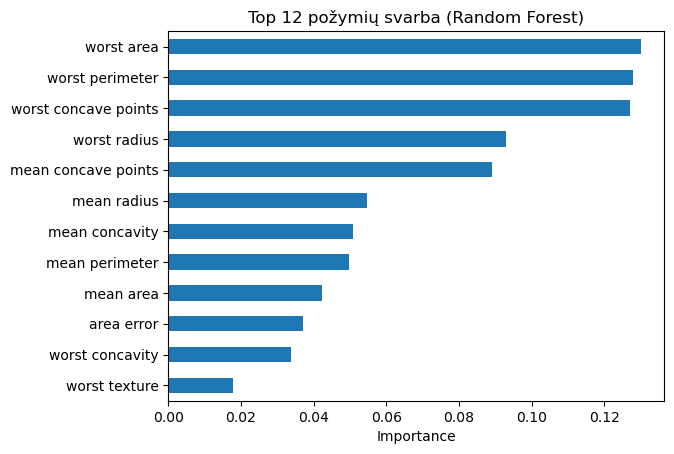

In [11]:
top_n = 12
ax = importances.head(top_n).sort_values().plot(kind="barh")
ax.set_title(f"Top {top_n} požymių svarba (Random Forest)")
ax.set_xlabel("Importance")
plt.show()


## 6. Random Forest tuning (RandomizedSearchCV)

Hiperparametrai valdo modelio sudėtingumą ir kompromisą tarp bias/variance.  
`RandomizedSearchCV` išbando ribotą atsitiktinių kombinacijų skaičių ir dažnai yra greitesnis už pilną `GridSearchCV`.

Geroji praktika: naudoti `scoring` pagal tikimybes (pvz., ROC AUC), jei tikimybės svarbios.


In [12]:
rf_tune = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

param_dist_rf = {
    "n_estimators": [200, 400, 700],
    "max_depth": [None, 4, 6, 10],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

rand_rf = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rand_rf.fit(X_train, y_train)

best_rf = rand_rf.best_estimator_
rand_rf.best_params_, rand_rf.best_score_


({'n_estimators': 200,
  'min_samples_leaf': 2,
  'max_features': 'sqrt',
  'max_depth': None,
  'bootstrap': False},
 0.9907636738906088)

Geriausia rasta hiperparametrų kombinacija rodo, kad modelis veikia optimaliai su 200 medžių (**n_estimators = 200**). Didesnis medžių skaičius padidina modelio stabilumą ir sumažina atsitiktinių svyravimų įtaką.

**max_depth = None** reiškia, kad medžių gylis nėra ribojamas. Medžiai gali augti tol, kol išskiria duomenis maksimaliai detaliai. Tokia struktūra leidžia modeliui sugauti sudėtingus ryšius, tačiau gali didinti persimokymo riziką.

**min_samples_leaf = 2** reiškia, kad kiekviename galiniame mazge turi būti bent dvi stebėsenos. Tai padeda šiek tiek sumažinti modelio jautrumą pavieniams atvejams ir pagerina bendrą stabilumą.

**max_features = 'sqrt'** reiškia, kad kiekviename skaidyme vertinama tik dalis požymių (kvadratinė šaknis iš visų kintamųjų skaičiaus). Tai padidina medžių įvairovę ir sumažina jų tarpusavio koreliaciją, o tai yra viena pagrindinių Random Forest stiprybių.

**bootstrap = False** reiškia, kad kiekvienas medis treniruojamas naudojant visą treniravimo imtį, o ne atsitiktinę imtį su grąžinimu. Tai sumažina atsitiktinumą, bet gali šiek tiek sumažinti medžių įvairovę.

Vidutinė kryžminės validacijos ROC AUC reikšmė yra **0.9908**, kas rodo labai aukštą modelio gebėjimą atskirti klases. Modelis beveik idealiai atskiria piktybinius ir nepiktybinius atvejus treniravimo fazėje.


In [13]:
res_best_rf = evaluate_classifier(best_rf, X_test, y_test, "Random Forest (tuned)")


Random Forest (tuned)
  Accuracy: 0.9561
  ROC AUC : 0.9937
  Confusion matrix:
 [[39  3]
 [ 2 70]]
  Classification report:
               precision    recall  f1-score   support

           0      0.951     0.929     0.940        42
           1      0.959     0.972     0.966        72

    accuracy                          0.956       114
   macro avg      0.955     0.950     0.953       114
weighted avg      0.956     0.956     0.956       114



Po hiperparametrų optimizavimo modelio **Accuracy** išlieka 0.9561. Tai reiškia, kad apie 95.6% testinių atvejų klasifikuojami teisingai. Galutinės klasės prognozės nepasikeitė, todėl confusion matrix išliko tokia pati.

Iš 42 neigiamos klasės atvejų 39 atpažinti teisingai, o 3 – suklysti. Iš 72 teigiamos klasės atvejų 70 atpažinti teisingai, o 2 – suklysti. Modelis išlaiko aukštą jautrumą ir specifiškumą.

Precision ir recall reikšmės taip pat išlieka aukštos. Teigiamos klasės recall yra 0.972, todėl modelis aptinka apie 97% piktybinių atvejų.

Svarbus pokytis matomas ROC AUC rodiklyje – jis padidėjo iki 0.9937. Tai reiškia, kad modelis dar geriau atskiria klases pagal tikimybes, net jei galutinės klasės prognozės nepasikeitė.

Praktinė išvada: hiperparametrų optimizavimas pagerino modelio tikimybinį atskyrimą, tačiau nepakako pakeisti galutinės klasifikacijos rezultatų. Tai rodo, kad pradinis modelis jau buvo labai stiprus, o tuning davė nedidelį, bet pozityvų patobulinimą.


Dažnos klaidos derinant modelius:
- Derinimas atliekamas pagal test rinkinį (taip „nuteka“ informacija).
- Derinama per daug parametrų vienu metu su labai plačiomis ribomis (labai lėta).
- Nelyginamos metrikos (pvz., lyginama ROC AUC su accuracy skirtinguose bandymuose).


## 7. Gradient Boosted Machines (GBM)

GBM (Gradient Boosting) treniruoja medžius **nuosekliai**. Kiekvienas naujas medis taiso ankstesnio modelio klaidas.  
Dažnai pasiekiamas labai aukštas tikslumas, bet modelis tampa jautresnis hiperparametrams.

Praktinė pastaba: `learning_rate` ir `n_estimators` dažnai derinami kartu (mažesnis `learning_rate` paprastai reikalauja daugiau medžių).


In [14]:
gbm = GradientBoostingClassifier(random_state=RANDOM_STATE)
gbm.fit(X_train, y_train)

res_gbm = evaluate_classifier(gbm, X_test, y_test, "Gradient Boosting (default)")


Gradient Boosting (default)
  Accuracy: 0.9561
  ROC AUC : 0.9907
  Confusion matrix:
 [[38  4]
 [ 1 71]]
  Classification report:
               precision    recall  f1-score   support

           0      0.974     0.905     0.938        42
           1      0.947     0.986     0.966        72

    accuracy                          0.956       114
   macro avg      0.961     0.945     0.952       114
weighted avg      0.957     0.956     0.956       114



Gradient Boosting modelio **Accuracy** yra 0.9561, todėl apie 95.6% testinių atvejų klasifikuojami teisingai. Bendras tikslumas panašus į Random Forest modelį.

Confusion matrix rodo nedidelį skirtumą pasiskirstyme. Iš 42 neigiamos klasės atvejų 38 atpažinti teisingai, o 4 – suklysti. Iš 72 teigiamos klasės atvejų 71 atpažintas teisingai, o tik 1 – suklystas. Modelis šiek tiek geriau aptinka teigiamą klasę, tačiau truputį prasčiau – neigiamą.

Teigiamos klasės recall yra 0.986, todėl aptinkama beveik 99% piktybinių atvejų. Tai labai aukštas jautrumas. Precision 1 klasei yra 0.947, todėl dalis teigiamų prognozių gali būti klaidingos.

ROC AUC yra 0.9907. Tai rodo labai stiprų klasių atskyrimą pagal tikimybes, nors šiek tiek mažesnį nei tuned Random Forest.

Praktinė išvada: Gradient Boosting modelis labiau orientuotas į teigiamos klasės atpažinimą ir beveik nepalieka nepastebėtų piktybinių atvejų. Tačiau tai pasiekiama šiek tiek padidinant klaidų skaičių neigiamoje klasėje.


## 8. GBM tuning

Toliau atliekamas derinimas. Čia naudojamas `GridSearchCV` su santykinai mažu tinkleliu, kad demonstracija būtų greita.

Dažna klaida: vienu metu didinti ir `n_estimators`, ir `learning_rate` iki agresyvių reikšmių, o tada gauti persimokymą.


In [15]:
gbm_tune = GradientBoostingClassifier(random_state=RANDOM_STATE)

param_grid_gbm = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 1.0],
    "max_features": [None, "sqrt"]
}

grid_gbm = GridSearchCV(
    estimator=gbm_tune,
    param_grid=param_grid_gbm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_gbm.fit(X_train, y_train)

best_gbm = grid_gbm.best_estimator_
grid_gbm.best_params_, grid_gbm.best_score_


({'learning_rate': 0.1,
  'max_depth': 3,
  'max_features': 'sqrt',
  'min_samples_leaf': 4,
  'n_estimators': 200,
  'subsample': 0.8},
 0.993704850361197)

Geriausia rasta Gradient Boosting hiperparametrų kombinacija rodo, kad modelis optimaliai veikia su 200 medžių (**n_estimators = 200**) ir **learning_rate = 0.1**. Tai reiškia, kad kiekvienas medis daro vidutinio dydžio korekciją ankstesnio modelio klaidoms.

**max_depth = 3** reiškia, kad kiekvienas medis yra negilus. Tokie medžiai paprastai veikia kaip silpni mokytojai, o jų kombinacija sudaro stiprų modelį. Tai sumažina persimokymo riziką.

**min_samples_leaf = 4** reiškia, kad kiekviename galiniame mazge turi būti bent keturios stebėsenos. Tai padeda išvengti pernelyg detalaus prisitaikymo prie pavienių atvejų.

**max_features = 'sqrt'** reiškia, kad kiekviename skaidyme naudojama tik dalis požymių. Tai padidina modelio stabilumą ir sumažina koreliaciją tarp medžių.

**subsample = 0.8** reiškia, kad kiekvienas medis treniruojamas naudojant 80% treniravimo duomenų. Tai įveda papildomą atsitiktinumą ir veikia kaip reguliarizacija, mažindama persimokymo riziką.

Vidutinė kryžminės validacijos ROC AUC reikšmė yra **0.9937**, kas rodo labai aukštą modelio gebėjimą atskirti klases. Modelis demonstruoja beveik idealų tikimybinį atskyrimą treniravimo ir validacijos etape.


In [16]:
res_best_gbm = evaluate_classifier(best_gbm, X_test, y_test, "Gradient Boosting (tuned)")


Gradient Boosting (tuned)
  Accuracy: 0.9561
  ROC AUC : 0.9937
  Confusion matrix:
 [[38  4]
 [ 1 71]]
  Classification report:
               precision    recall  f1-score   support

           0      0.974     0.905     0.938        42
           1      0.947     0.986     0.966        72

    accuracy                          0.956       114
   macro avg      0.961     0.945     0.952       114
weighted avg      0.957     0.956     0.956       114



Po hiperparametrų optimizavimo **Accuracy** išlieka 0.9561, todėl galutinių klasės prognozių tikslumas nepasikeitė. Confusion matrix taip pat išlieka tokia pati kaip ir numatytojo modelio atveju.

Iš 42 neigiamos klasės atvejų 38 atpažinti teisingai, o 4 – suklysti. Iš 72 teigiamos klasės atvejų 71 atpažintas teisingai, o tik 1 – suklystas. Modelis išlaiko labai aukštą teigiamos klasės jautrumą.

Teigiamos klasės recall yra 0.986, todėl beveik visi piktybiniai atvejai aptinkami. Precision 1 klasei yra 0.947, tai reiškia, kad nedidelė dalis teigiamų prognozių gali būti klaidingos.

ROC AUC padidėjo iki 0.9937. Tai rodo geresnį tikimybinį atskyrimą tarp klasių, net jei galutinės klasifikacijos ribos nepakeitė tikslumo.

Praktinė išvada: hiperparametrų optimizavimas pagerino modelio tikimybių kokybę, tačiau galutinės klasės sprendimai nepasikeitė. Modelis išlieka stipriai orientuotas į teigiamos klasės aptikimą ir pasižymi labai aukštu jautrumu.


## 9. Papildoma metrika: ROC ir PR kreivės

ROC kreivė tinkama, kai domina atskyrimo kokybė.  
PR (Precision-Recall) kreivė dažnai naudingesnė, kai teigiama klasė reta.

Dažna klaida: ignoruoti PR analizę, kai teigiama klasė sudaro mažą dalį.


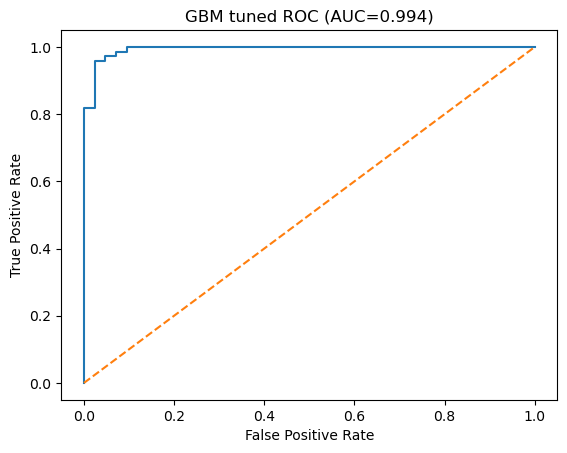

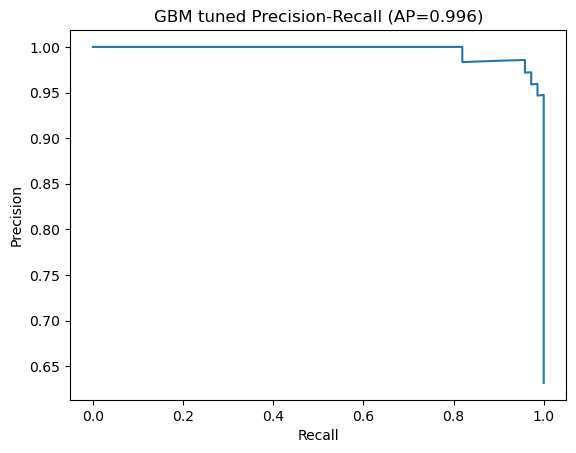

In [17]:
def plot_roc_pr(y_true, y_score, title_prefix="model"):
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{title_prefix} ROC (AUC={auc:.3f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"{title_prefix} Precision-Recall (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# Pavyzdys su tuned GBM
plot_roc_pr(y_test, res_best_gbm["y_proba"], "GBM tuned")


ROC kreivė rodo, kaip modelis atskiria klases keičiant sprendimo slenkstį.

Kreivė yra labai arti kairiojo viršutinio kampo. Tai reiškia, kad modelis pasiekia aukštą True Positive Rate esant labai mažam False Positive Rate. Kitaip tariant, dauguma teigiamų atvejų aptinkami dar prieš pradedant daryti daugiau klaidų neigiamos klasės atžvilgiu.

AUC = 0.994 rodo beveik tobulą klasių atskyrimą. Vertė arti 1 reiškia, kad modelis labai gerai skiria piktybinius ir nepiktybinius atvejus pagal prognozuojamas tikimybes.

Praktinė interpretacija: modelis generuoja labai gerai atskirtas tikimybes. Net pakeitus klasifikavimo slenkstį, galima išlaikyti aukštą jautrumą ir tuo pačiu kontroliuoti klaidingų teigiamų atvejų skaičių.

Svarbu suprasti, kad ROC vertina tikimybių kokybę, o ne konkretų sprendimo slenkstį. Todėl aukštas AUC nebūtinai reiškia didesnį accuracy, tačiau rodo gerą modelio diskriminacinę galią.

Precision–Recall kreivė rodo santykį tarp jautrumo (recall) ir tikslumo (precision), keičiant sprendimo slenkstį.

Kreivė beveik visame intervale išlieka arti 1. Tai reiškia, kad modelis sugeba aptikti beveik visus teigiamus atvejus išlaikydamas labai aukštą prognozių tikslumą. Kitaip tariant, didinant recall, precision išlieka aukštas.

AP = 0.996 rodo beveik idealų rezultatą. Average Precision vertė arti 1 reiškia, kad modelis labai gerai atskiria klases net tada, kai vertinamas tik teigiamos klasės aptikimas.

Praktinė interpretacija: modelis labai retai pažymi nepiktybinį atvejį kaip piktybinį ir tuo pačiu nepraleidžia daug tikrų piktybinių atvejų. Tai ypač svarbu medicininiuose duomenyse, kur klaidingai neaptikti teigiami atvejai gali turėti rimtas pasekmes.

Precision–Recall analizė yra ypač naudinga, kai klasės nėra subalansuotos, nes ji labiau koncentruojasi į teigiamos klasės aptikimo kokybę nei ROC kreivė.



## 10. SHAP values (modelio paaiškinamumas)

SHAP leidžia paaiškinti, kaip požymiai pastumia prognozę nuo bazinės (vidutinės) reikšmės iki konkretaus atvejo prognozės.

Svarbi praktinė detalė: `shap.plots.*` funkcijoms reikia **Explanation** objekto.  
Todėl naudojamas kvietimas `explainer(X)` (ne `explainer.shap_values(X)`), nes pastarasis dažnai grąžina numpy masyvą.

Dažna klaida: maišyti naują `shap.plots` API su sena `.shap_values()` iškvieta.


In [18]:
import shap

# Maža imtis, kad grafikai būtų greitesni
X_shap = X_test.sample(80, random_state=RANDOM_STATE)

# Explainer + Explanation objektas
explainer = shap.Explainer(best_gbm)
shap_values = explainer(X_shap)

type(shap_values), shap_values.shape


(shap._explanation.Explanation, (80, 30))

### 10.1 SHAP waterfall plot (vienai prognozei)

Waterfall grafikas parodo, kurie požymiai konkrečiu atveju didino arba mažino prognozę.

Pastaba: jei reikia vienos eilutės, galima naudoti vieną iškvietimą, bet aiškumui paliekami atskiri žingsniai.


In [31]:
X_shap.iloc[1, :]

mean radius                  21.560000
mean texture                 22.390000
mean perimeter              142.000000
mean area                  1479.000000
mean smoothness               0.111000
mean compactness              0.115900
mean concavity                0.243900
mean concave points           0.138900
mean symmetry                 0.172600
mean fractal dimension        0.056230
radius error                  1.176000
texture error                 1.256000
perimeter error               7.673000
area error                  158.700000
smoothness error              0.010300
compactness error             0.028910
concavity error               0.051980
concave points error          0.024540
symmetry error                0.011140
fractal dimension error       0.004239
worst radius                 25.450000
worst texture                26.400000
worst perimeter             166.100000
worst area                 2027.000000
worst smoothness              0.141000
worst compactness        

In [30]:
shap_values

.values =
array([[-0.13036499,  0.01954672,  0.11177969, ...,  0.77600313,
        -0.18948573,  0.05398923],
       [-0.28385575, -0.74397214, -0.26326095, ..., -2.29377054,
         0.18044267,  0.00774831],
       [ 0.05532516, -0.034734  ,  0.11300375, ...,  1.37810126,
        -0.1782251 ,  0.03302034],
       ...,
       [ 0.07221015, -0.76640209,  0.2245066 , ...,  1.21521071,
         0.43906979,  0.02144993],
       [-0.26842653,  0.51396971, -0.49491155, ...,  0.30681429,
         0.47462413, -0.02409778],
       [-0.03910929, -0.02161574,  0.13120531, ...,  0.72709216,
         0.4524996 ,  0.03286111]])

.base_values =
array([2.90043698, 2.90043698, 2.90043698, 2.90043698, 2.90043698,
       2.90043698, 2.90043698, 2.90043698, 2.90043698, 2.90043698,
       2.90043698, 2.90043698, 2.90043698, 2.90043698, 2.90043698,
       2.90043698, 2.90043698, 2.90043698, 2.90043698, 2.90043698,
       2.90043698, 2.90043698, 2.90043698, 2.90043698, 2.90043698,
       2.90043698, 2.90043

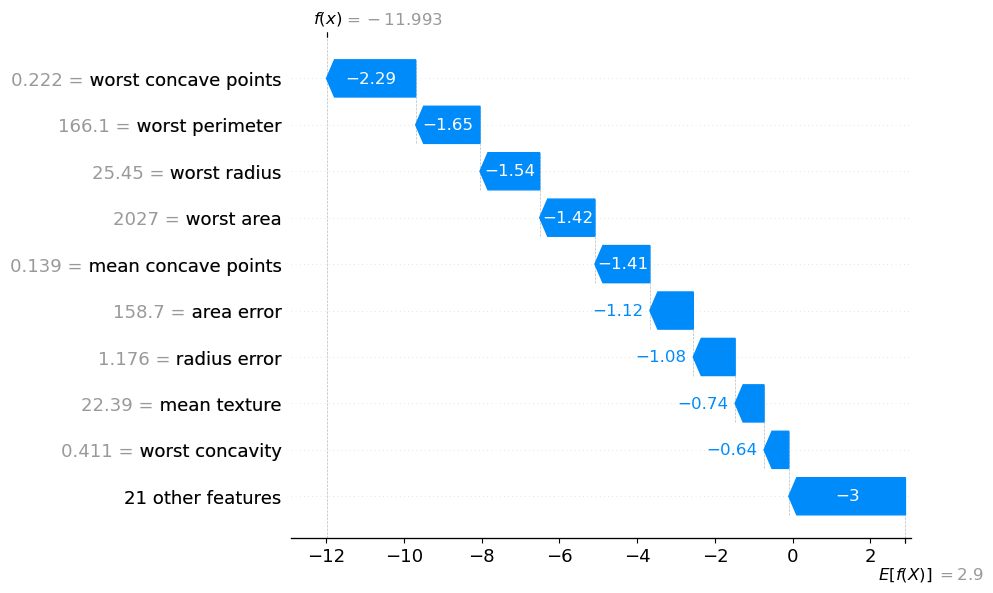

In [20]:
shap.plots.waterfall(shap_values[1])


Waterfall grafikas parodo, kaip atskiro stebėjimo prognozė susiformuoja iš bazinės reikšmės.

E[f(X)] = 2.9 – tai vidutinė modelio prognozė (bazinis lygis visiems stebėjimams).

f(x) = -11.993 – tai galutinė modelio reikšmė šiam konkrečiam atvejui (log-odds skalėje). Neigiama reikšmė rodo labai mažą tikimybę priklausyti teigiamai klasei.

Kiekviena juosta rodo, kiek konkretus požymis pastumia prognozę:

- worst concave points (-2.29) stipriai mažina tikimybę.
- worst perimeter (-1.65) papildomai mažina prognozę.
- worst radius (-1.54) taip pat reikšmingai mažina.
- worst area (-1.42) ir mean concave points (-1.41) turi neigiamą įtaką.
- area error ir radius error dar labiau stumia prognozę žemyn.
- Likę 21 požymiai kartu sumažina prognozę apie -3.

Visi pagrindiniai požymiai šiame pavyzdyje veikia viena kryptimi – mažina modelio išvestį, todėl galutinė prognozė tampa stipriai neigiama.

Interpretacija paprasta: šio paciento požymių kombinacija modelio požiūriu labiau būdinga neigiamai klasei, todėl tikimybė teigiamai klasei yra labai maža.


### 10.2 SHAP beeswarm plot

Beeswarm grafikas yra „išplėstinė feature importance“ versija:  
parodoma ne tik svarba, bet ir poveikio kryptis bei poveikio pasiskirstymas per stebėjimus.


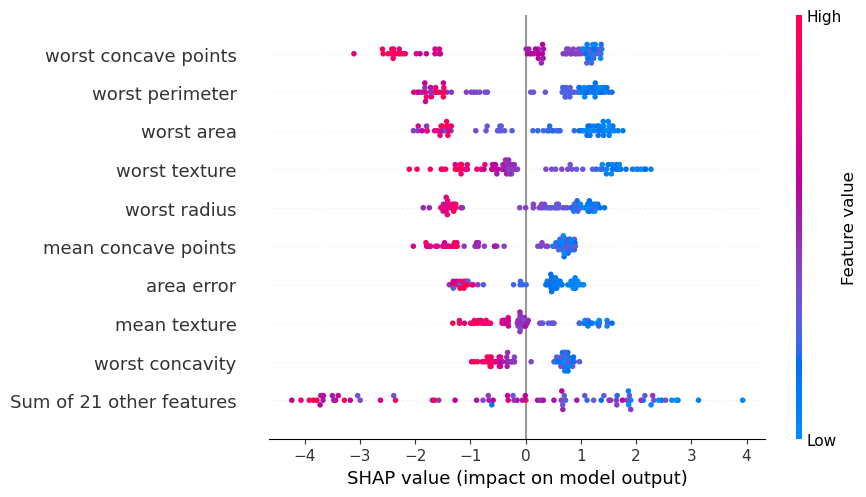

In [21]:
shap.plots.beeswarm(shap_values)


Beeswarm grafikas parodo, kurie požymiai stipriausiai veikia modelio prognozes ir kokia kryptimi jie veikia.

Horizontalioje ašyje pateikiama SHAP reikšmė. 
Teigiama reikšmė reiškia, kad požymis didina teigiamos klasės tikimybę. 
Neigiama reikšmė reiškia, kad požymis ją mažina.

Spalva rodo realią požymio reikšmę:
mėlyna – maža reikšmė,
raudona – didelė reikšmė.

Svarbiausi požymiai yra:
- worst concave points
- worst perimeter
- worst area
- worst texture
- worst radius

Matoma aiški struktūra:
didelės šių požymių reikšmės (raudoni taškai) dažniausiai stumia prognozę į neigiamą pusę, 
o mažos reikšmės (mėlyni taškai) – į teigiamą pusę.

Tai reiškia, kad didesni naviko dydžio ir struktūros rodikliai modelio požiūriu labiau siejami su piktybiškumu, todėl mažina tikimybę būti priskirtam gerybinei klasei.

„Sum of 21 other features“ rodo, kad likę požymiai turi mažesnį, labiau išsisklaidžiusį poveikį. Jų įtaka yra silpnesnė ir mažiau sisteminga.

Išvada: modelio sprendimus daugiausia lemia keli aiškūs morfologiniai požymiai, o likusieji veikia tik papildomai.


### 10.3 SHAP dependence plot (scatter)

Dependence (scatter) grafikas rodo, kaip vieno požymio reikšmės susijusios su poveikiu prognozei.  
Papildomai dažnai nuspalvinama pagal kitą požymį, kad matytųsi sąveika.

Pastaba: žemiau pateikiamas pavyzdys su dviem dažnai naudojamais požymiais iš šio duomenų rinkinio.


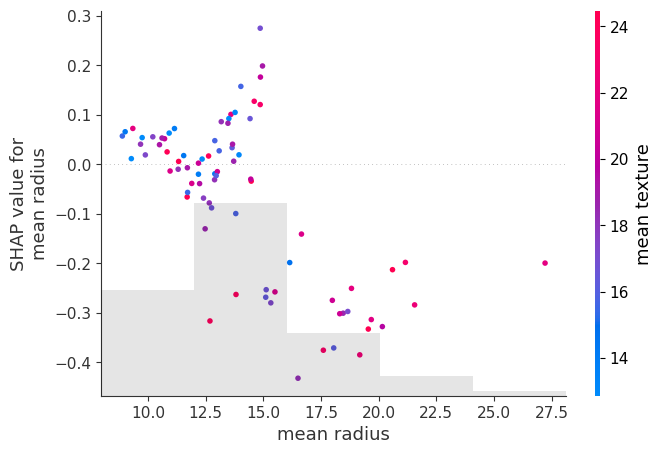

In [22]:
# X ašis: mean radius, spalva: mean texture (sąveikos užuomina)
shap.plots.scatter(
    shap_values[:, "mean radius"],
    color=shap_values[:, "mean texture"]
)


SHAP dependence grafikas rodo, kaip požymis „mean radius“ veikia modelio prognozę ir kaip ši įtaka sąveikauja su „mean texture“.

Horizontalioje ašyje pateikiama „mean radius“ reikšmė.
Vertikalioje ašyje – šio požymio SHAP reikšmė, t. y. jo indėlis į modelio sprendimą.
Spalva rodo „mean texture“ dydį (mėlyna – mažesnė reikšmė, rožinė – didesnė).

Matoma aiški tendencija:
- Mažesnės „mean radius“ reikšmės dažniau turi teigiamą arba artimą nuliui SHAP poveikį.
- Didėjant „mean radius“, SHAP reikšmė tampa vis labiau neigiama.

Tai reiškia, kad didesnis vidutinis spindulys mažina tikimybę būti priskirtam gerybinei klasei (didina piktybiškumo tikimybę).

Spalvų pasiskirstymas rodo sąveiką:
- Esant didelėms „mean texture“ reikšmėms, poveikis dažnai tampa dar labiau neigiamas.
- Tai rodo, kad spindulio ir tekstūros kombinacija stiprina modelio sprendimą.

Išvada: „mean radius“ turi aiškią, monotonišką įtaką prognozei, o „mean texture“ sustiprina šį efektą tam tikruose reikšmių intervaluose. Modelis fiksuoja ne tik atskirų požymių poveikį, bet ir jų tarpusavio sąveiką.


Labai paprastai:

Šis grafikas rodo, kaip naviko dydis (mean radius) veikia modelio sprendimą.

Jei „mean radius“ yra mažas, modelis labiau linkęs prognozuoti gerybinį atvejį.

Jei „mean radius“ yra didelis, modelis labiau linkęs prognozuoti piktybinį atvejį.

Spalva rodo kitą požymį – „mean texture“. Kai tekstūra taip pat didelė, modelis dar stipriau linksta į piktybinę prognozę.

Trumpai:
didesnis naviko dydis → didesnė piktybiškumo tikimybė.
Tekstūra gali šį efektą sustiprinti.


## 11. Santrauka, dažnos klaidos ir gerosios praktikos

Santrauka:
- Voting ansambliai apjungia kelių bazinių modelių prognozes (hard/soft).  
- Random Forest suteikia stabilų rezultatą per medžių vidurkinimą (bagging).  
- Gradient Boosting dažnai pasiekia aukštą tikslumą per nuoseklų klaidų taisymą (boosting).  
- SHAP padeda paaiškinti sudėtingus modelius tiek individualiai, tiek globaliai.

Dažnos klaidos:
- Remtis vien tik accuracy ir nežiūrėti į confusion matrix / ROC AUC.  
- Derinti hiperparametrus pagal test rinkinį.  
- Naudoti SHAP `.shap_values()` ir tikėtis, kad `shap.plots.*` veiks be Explanation objekto.  
- Daryti labai platų GridSearch ir gauti neadekvačiai ilgą vykdymą.

Gerosios praktikos:
- Naudoti cross-validation derinimui ir test rinkinį laikyti galutiniam įvertinimui.  
- ROC AUC naudoti, kai svarbios tikimybės ir klasės atskyrimas.  
- PR kreivę įtraukti, kai teigiama klasė reta.  
- SHAP interpretacijai naudoti `explainer(X)` ir dirbti su `Explanation` objektu.
